In [1]:
import rebayes_mini
import jax
jax.config.update("jax_enable_x64", True)
import chex
import numpy as np
import pandas as pd
import seaborn as sns
import jax.numpy as jnp
import matplotlib.pyplot as plt
from functools import partial
from rebayes_mini import callbacks
from rebayes_mini.states import GaussState
import pickle, os, sys, time, platform
from tqdm import tqdm

from profilter import ExtendedKalmanFilter
from profilter_rebuttal import PrOFilter
from unscented import UnscentedKalmanFilter, UKFPrOFilterPred, CubatureKalmanFilter, CKFPrOFilterPred

cmap = {
    "EKF": "lightseagreen",
    "UKF": "teal",
    "CKF": "slateblue",
    "EKF-PrO": "mediumorchid",
    "UKF-PrO": "deeppink",
    "CKF-PrO": "darkgoldenrod",
}

def euler_step(y, i, dt, f):
    h = dt
    t = dt * i
    k1 = h * f(y, t, i)
    return y + k1

def rk4_step(y, i, dt, f):
    h = dt
    t = dt * i
    k1 = h * f(y, t, i)
    k2 = h * f(y + k1 / 2, dt * i + h / 2, i)
    k3 = h * f(y + k2 / 2, t + h / 2, i)
    k4 = h * f(y + k3, t + h, i)

    y_next = y + 1 / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
    return y_next

@partial(jax.jit, static_argnames=("f",))
def solve(ys, dt, N, f):
    @jax.jit
    def step(i, ys):
        ysi = euler_step(ys[i - 1], i, dt, f)
        return ys.at[i].set(ysi)
    return jax.lax.fori_loop(1, N, step, ys)

In [2]:
def get_environment_info():
    return {
        "python_version": sys.version,
        "platform": platform.platform(),
        "processor": platform.processor(),
        "jax_version": jax.__version__,
        "jax_backend": jax.default_backend(),
        "numpy_version": np.__version__,
    }

env_info = get_environment_info()
print(env_info)

{'python_version': '3.11.5 (main, Aug  4 2026, 12:20:09) [Clang 17.0.0 (clang-1700.0.13.5)]', 'platform': 'macOS-15.7.9-x86_64-i386-64bit', 'processor': 'i386', 'jax_version': '0.4.38', 'jax_backend': 'cpu', 'numpy_version': '2.3.5'}


In [3]:
D = 10
N = 1000
dt = 0.002
sigma = 1.0
F = 8.0
n_hidden = 2
transition_prob = 0.995
observation_covariance = 5.0

A_OBS = 0.9
OMEGA_OBS = 10.0

@partial(jax.vmap, in_axes=(None, 0, None))
def fcoord(x, k, D):
    xdot = (x[(k + 1) % D] - x[k - 2]) * x[k - 1] - x[k] + F
    return xdot

def obs_fn(x, _):
    return x + (A_OBS / OMEGA_OBS) * jnp.sin(OMEGA_OBS * x)

def latent_fn(x):
    @jax.jit
    def f(x, t, _):
        ixs = jnp.arange(D)
        return fcoord(x, ixs, D)
    return euler_step(x, 0, dt, f)

def get_mean_and_cov(bel, bel_pred, y, x):
    return bel.mean, bel.cov

def nll_step(x_true, mean, cov):
    d = mean.shape[0]
    diff = x_true - mean
    sign, logdet = jnp.linalg.slogdet(cov)
    quad = diff @ jnp.linalg.solve(cov, diff)
    return 0.5 * (quad + logdet + d * jnp.log(2 * jnp.pi))

def generate_data(seed):
    key = jax.random.PRNGKey(seed)
    key_init, key_sim, key_eval = jax.random.split(key, 3)
    key_state, key_measurement = jax.random.split(key_sim)

    key_hidden, key_state = jax.random.split(key_state)
    transition_state = jnp.ones((n_hidden, n_hidden)) * 1/(n_hidden-1) * (1-transition_prob)
    transition_state = transition_state.at[jnp.diag_indices_from(transition_state)].set(transition_prob)

    key_hidden, key_state = jax.random.split(key_state)
    phi_hidden = jax.random.normal(key_hidden, (D, n_hidden-1)) * sigma
    phi_hidden = jnp.concatenate([jnp.zeros((D, 1)), phi_hidden], -1)

    @jax.jit
    def f(x, t, i, regime):
        keyt = jax.random.fold_in(key_state, i)
        key_regime, keyt = jax.random.split(keyt)
        probabilities = transition_state[regime, :]
        logits = jnp.log(probabilities)
        regime_next = jax.random.categorical(key_regime, logits)
        ixs = jnp.arange(D)
        xdot = fcoord(x, ixs, D) + phi_hidden[:, regime_next]
        return xdot, regime_next

    x0 = jax.random.normal(key_init, (D,))
    x_init = jnp.copy(x0)
    xs = jnp.zeros((N,) + x0.shape)
    xs = xs.at[0].set(x0)
    regime = int(0)
    for i in range(1, N):
        xdot, regime = f(x0, i * dt, i, regime)
        x0 = x0 + dt * xdot
        xs = xs.at[i].set(x0)

    ys = obs_fn(xs, None) + jnp.sqrt(observation_covariance) * jax.random.normal(key_measurement, xs.shape)
    return xs, ys, x_init

In [4]:
from unscented import CKFPrOFilterPred, CKFPrOFilter

SEEDS = list(range(1, 11))
RESULTS_FILE = "ckf_vs_ckfplus_nonlinear_h_results.pkl"

methods_cfg = {
    "CKF-PrO":  (CKFPrOFilterPred, dict(n_inner=5,  n_outer=10)),
    "CKF-PrO+": (CKFPrOFilter,     dict(n_inner=50, n_outer=10)),
}

all_results = pickle.load(open(RESULTS_FILE, "rb")) if os.path.exists(RESULTS_FILE) else {}

for seed in tqdm(SEEDS):
    if seed in all_results and all(m in all_results[seed] for m in methods_cfg):
        continue
    xs, ys, x_init = generate_data(seed)
    nsteps = xs.shape[0]
    res = all_results.get(seed, {"_environment": env_info})

    for method, (cls, kwargs) in methods_cfg.items():
        if method in res:
            continue
        t0 = time.time()
        agent = cls(
            latent_fn, obs_fn,
            dynamics_covariance=jnp.eye(D) * jnp.square(sigma * dt),
            observation_covariance=observation_covariance * jnp.eye(D),
            **kwargs,
        )
        init_bel = agent.init_bel(x_init, cov=1.0)
        filterfn = partial(agent.scan, callback_fn=get_mean_and_cov)
        _, (hist, hist_cov) = filterfn(init_bel, ys, jnp.ones(nsteps))
        hist.block_until_ready()
        hist_cov.block_until_ready()
        elapsed = time.time() - t0

        err = jnp.sqrt(jnp.sum(jnp.square(hist - xs), -1))
        mse = jnp.sum(jnp.square(hist - xs))
        nll_per_step = jax.vmap(nll_step)(xs, hist, hist_cov)

        res[method] = {
            "mse": float(mse),
            "mean_nll": float(jnp.mean(nll_per_step)),
            "mean_error": float(jnp.mean(err)),
            "wall_clock_seconds": elapsed,
        }
        print(f"seed {seed} {method}: mean error = {jnp.mean(err):.4f}, MSE = {mse:.4f}, "
              f"mean NLL = {jnp.mean(nll_per_step):.4f}, time = {elapsed:.1f}s")

    all_results[seed] = res
    pickle.dump(all_results, open(RESULTS_FILE, "wb"))

  0%|          | 0/10 [00:00<?, ?it/s]

seed 1 CKF-PrO: mean error = 0.7176, MSE = 599.1545, mean NLL = -7.5970, time = 7.4s


 10%|█         | 1/10 [01:10<10:36, 70.76s/it]

seed 1 CKF-PrO+: mean error = 0.7359, MSE = 636.5394, mean NLL = -6.7044, time = 59.2s
seed 2 CKF-PrO: mean error = 0.7944, MSE = 712.3287, mean NLL = 22.9441, time = 7.9s


 20%|██        | 2/10 [02:07<08:17, 62.22s/it]

...

seed 8 CKF-PrO+: mean error = 1.1874, MSE = 1695.0311, mean NLL = 164.2116, time = 56.2s
seed 9 CKF-PrO: mean error = 0.9238, MSE = 966.3939, mean NLL = 39.6178, time = 7.7s


 90%|█████████ | 9/10 [09:39<01:05, 65.79s/it]

seed 9 CKF-PrO+: mean error = 0.9763, MSE = 1047.5002, mean NLL = 17.8504, time = 62.0s
seed 10 CKF-PrO: mean error = 0.8047, MSE = 714.3035, mean NLL = 14.2209, time = 6.9s


100%|██████████| 10/10 [10:50<00:00, 65.05s/it]

seed 10 CKF-PrO+: mean error = 0.9760, MSE = 1024.2545, mean NLL = 21.2156, time = 63.1s


In [5]:
methods = ["CKF-PrO", "CKF-PrO+"]
done = sorted(s for s in all_results if all(m in all_results[s] for m in methods))
print(f"Seeds completed: {len(done)}\nSeed list: {done}\n")

for m in methods:
    print(f"{m}:")
    for key, label in [("mse", "MSE "), ("mean_nll", "NLL ")]:
        v = np.array([all_results[s][m][key] for s in done])
        print(f"  {label} -> mean={v.mean():.4f}, std={v.std():.4f}, min={v.min():.4f}, max={v.max():.4f}")
    t = np.array([all_results[s][m]["wall_clock_seconds"] for s in done])
    print(f"  time -> mean = {t.mean():.2f}s, std = {t.std():.2f}s\n")

for key in ["mse", "mean_nll"]:
    wins = sum(all_results[s]["CKF-PrO+"][key] < all_results[s]["CKF-PrO"][key] for s in done)
    print(f"CKF-PrO+ better than CKF-PrO on {key}: {wins}/{len(done)} seeds")

Seeds completed: 10
Seed list: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

CKF-PrO:
  MSE  -> mean=825.6348, std=258.6339, min=509.1944, max=1325.4640
  NLL  -> mean=38.4650, std=48.1882, min=-7.5970, max=162.4734
  time -> mean = 7.38s, std = 0.66s

CKF-PrO+:
  MSE  -> mean=1038.7632, std=263.5247, min=636.5394, max=1695.0311
  NLL  -> mean=36.1328, std=48.5311, min=-6.7044, max=164.2116
  time -> mean = 56.41s, std = 4.31s

CKF-PrO+ better than CKF-PrO on mse: 1/10 seeds
CKF-PrO+ better than CKF-PrO on mean_nll: 4/10 seeds


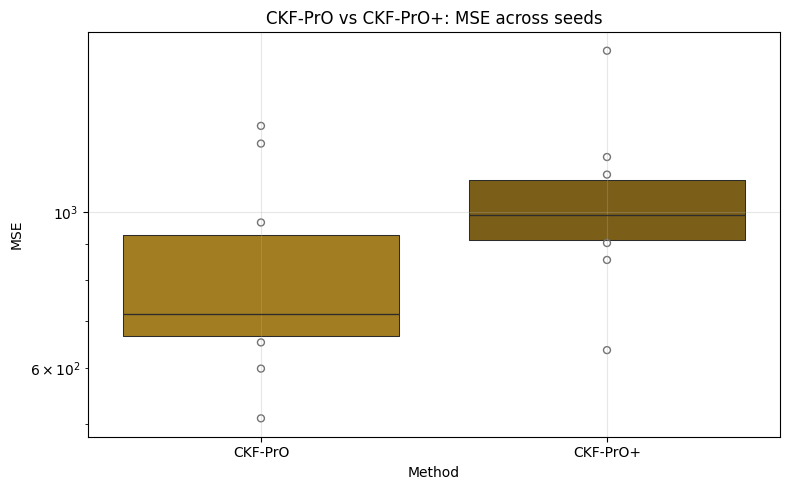

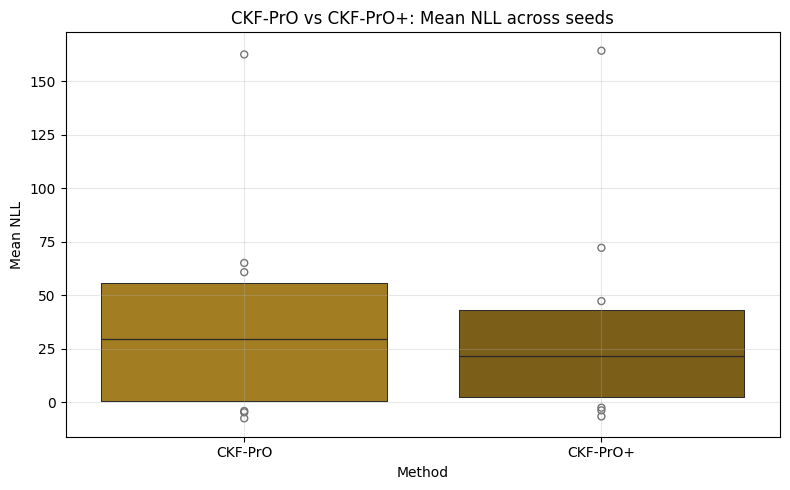

In [6]:
cmap_full = {"CKF-PrO": "darkgoldenrod", "CKF-PrO+": "#8B6508"}

df = pd.DataFrame([{"method": m, "seed": s,
                    "mse": all_results[s][m]["mse"],
                    "nll": all_results[s][m]["mean_nll"]}
                   for s in done for m in methods])

for col, ylabel, fname in [("mse", "MSE", "ckf_vs_ckfplus_mse.pdf"),
                           ("nll", "Mean NLL", "ckf_vs_ckfplus_nll.pdf")]:
    plt.figure(figsize=(8, 5))
    sns.boxenplot(data=df, x="method", y=col, hue="method", palette=cmap_full,
                  order=methods, legend=False)
    plt.xlabel("Method")
    plt.ylabel(ylabel)
    plt.grid(alpha=0.3)
    if col == "mse":
        plt.yscale("log")
    plt.title(f"CKF-PrO vs CKF-PrO+: {ylabel} across seeds")
    plt.tight_layout()
    plt.savefig(fname)
    plt.show()

df.to_csv("ckf_vs_ckfplus_results.csv", index=False)